In [8]:
# ============================================
# Jupyter Script: GP 自动挖掘 + 过滤 + 保存
# ============================================

from factors.factor_auto_search import GeneticFactorGenerator
import pandas as pd

# 1) 初始化 GeneticFactorGenerator（基于你给的参数）
fg = GeneticFactorGenerator(
    instrument_id_list='C0',
    start_time='20200101',
    end_time='20241231',
    version='20260330_gp_test',
    calculate_baseline=True,
    max_factor_count=50,
    rolling_norm_clip=5.0,  # 限制最大杠杆比
    gp_generations=50,
    fitness_metric='sharpe',
    gp_max_depth=4,
    gp_population_size=150,  # 每轮生成的因子数量
    gp_elite_size=30,        # 每轮前gp_elite_size个因子直接保留（不变异）进入下一轮
    gp_leaf_prob=0.3,
    gp_const_prob=0.02,
    gp_window_choices=[5, 10, 20],
    gp_depth_penalty_coef=0.0,
    gp_depth_penalty_start_depth=4,
    gp_depth_penalty_linear_coef=0.05,
    gp_depth_penalty_quadratic_coef=0.0,
    gp_early_stopping_generation_count=20,
    random_seed=42,
    # 新增参数（你要求）
    gp_assumed_initial_capital=100000,
    gp_small_factor_penalty_coef=0.0,
)

# 2) 过滤阈值（沿用项目内日常脚本的默认思路）
filter_indicator_dict = {
    'Net Return': (0.05, 0.03, 1),
    'Net Sharpe': (0.5, 0.3, 1),
}

# 3) 一键执行：自动挖掘 + 筛选 + 保存
result = fg.auto_mine_select_and_save_fc(
    filter_indicator_dict=filter_indicator_dict,
    n_jobs=5,
    require_all_row=True,
    require_all_instruments=True,
)

# 4) 查看结果
print("config_path:", result.get("config_path"))
print("selected_count:", len(result.get("selected_fc_name_list", [])))
print("selected_fc_name_list:", result.get("selected_fc_name_list", []))

bt = result.get("bt")
if bt is not None and getattr(bt, "performance_summary", None) is not None:
    print("\nperformance_summary tail:")
    display(bt.performance_summary.tail(10))

config_path: None
selected_count: 0
selected_fc_name_list: []

performance_summary tail:


,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,Net MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
year,,,,,,,,,,,,,,,,,,,,,
2022,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.15486,0.122289)","nan(0.267796,-0.267796)","nan(0.267796,-0.267796)","0(0.516529,0.466942)","0(0.516529,0.466942)","0(0,0)",fac_gp_0049,1d,0.0002,C0
2023,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.146334,0.115003)","nan(-1.08921,1.08921)","nan(-1.08921,1.08921)","0(0.483471,0.491736)","0(0.483471,0.491736)","0(0,0)",fac_gp_0049,1d,0.0002,C0
2024,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.176943,0.0575955)","nan(-1.37663,1.37663)","nan(-1.37663,1.37663)","0(0.417355,0.541322)","0(0.417355,0.541322)","0(0,0)",fac_gp_0049,1d,0.0002,C0
all,0.020537,0.020068,0.019122,0.018931,1.074025,1.060087,0.684334,0.651226,0.006849,0.006868,...,"0.00686784(0.30725,0.362493)","1.07403(0.176769,-0.176769)","1.06009(0.176421,-0.177116)","0.0247525(0.495875,0.480198)","0.0247525(0.495875,0.480198)","0.00929656(0.000825083,0.000825083)",fac_gp_0049,1d,0.0002,C0
2020,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.0487138,0.291679)","nan(2.75956,-2.75956)","nan(2.75777,-2.76134)","0(0.563786,0.411523)","0(0.563786,0.411523)","0(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
2021,0.102431,0.100094,0.042382,0.041970,2.416852,2.384916,3.413219,3.248090,0.006849,0.006868,...,"0.00686784(0.148106,0.111244)","2.41685(0.0391665,-0.0391665)","2.38492(0.0391665,-0.0391665)","0.123457(0.497942,0.489712)","0.123457(0.497942,0.489712)","0.046368(0,0)",fac_gp_0050,1d,0.0002,C0
2022,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.15486,0.122289)","nan(0.267796,-0.267796)","nan(0.267796,-0.267796)","0(0.516529,0.466942)","0(0.516529,0.466942)","0(0,0)",fac_gp_0050,1d,0.0002,C0
2023,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.146334,0.115003)","nan(-1.08921,1.08921)","nan(-1.08921,1.08921)","0(0.483471,0.491736)","0(0.483471,0.491736)","0(0,0)",fac_gp_0050,1d,0.0002,C0
2024,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,...,"0(0.176943,0.0575955)","nan(-1.37663,1.37663)","nan(-1.37663,1.37663)","0(0.417355,0.541322)","0(0.417355,0.541322)","0(0,0)",fac_gp_0050,1d,0.0002,C0


In [9]:
# 总体概括
bt = result['bt']
df_all = bt.performance_summary.loc[bt.performance_summary.index == 'all']
df_all = df_all.sort_values(by='Net Sharpe', ascending=False)
print(len(df_all['Factor Name'].tolist()))
top_fc_name = df_all['Factor Name'].tolist()[:10]
selected_fc_name_list = result['selected_fc_name_list']
print(len(selected_fc_name_list))

50
0


In [10]:
# 检查每年指标
df = bt.performance_summary.loc[bt.performance_summary.index != 'all'].reset_index()
check1 = df.groupby('Factor Name').apply(lambda x: all(x['Net Sharpe'] >= 0.3), include_groups=False).sort_values(ascending=False)
check2 = df.groupby('Factor Name').apply(lambda x: all(x['Net Return'] >= 0.03), include_groups=False).sort_values(ascending=False)
print(check1)

Factor Name
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0002    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [11]:
print(check2)

Factor Name
fac_gp_0001    False
fac_gp_0038    False
fac_gp_0028    False
fac_gp_0029    False
fac_gp_0030    False
fac_gp_0031    False
fac_gp_0032    False
fac_gp_0033    False
fac_gp_0034    False
fac_gp_0035    False
fac_gp_0036    False
fac_gp_0037    False
fac_gp_0039    False
fac_gp_0002    False
fac_gp_0040    False
fac_gp_0041    False
fac_gp_0042    False
fac_gp_0043    False
fac_gp_0044    False
fac_gp_0045    False
fac_gp_0046    False
fac_gp_0047    False
fac_gp_0048    False
fac_gp_0049    False
fac_gp_0027    False
fac_gp_0026    False
fac_gp_0025    False
fac_gp_0024    False
fac_gp_0003    False
fac_gp_0004    False
fac_gp_0005    False
fac_gp_0006    False
fac_gp_0007    False
fac_gp_0008    False
fac_gp_0009    False
fac_gp_0010    False
fac_gp_0011    False
fac_gp_0012    False
fac_gp_0013    False
fac_gp_0014    False
fac_gp_0015    False
fac_gp_0016    False
fac_gp_0017    False
fac_gp_0018    False
fac_gp_0019    False
fac_gp_0020    False
fac_gp_0021    False
f

In [17]:
df

,year,Gross Return,Net Return,Gross Volatility,Net Volatility,Gross Sharpe,Net Sharpe,Gross Sortino,Net Sortino,Gross MaxDD,...,Net MaxDD (With Baseline),Gross Calmar (With Baseline),Net Calmar (With Baseline),Gross Win Rate (With Baseline),Net Win Rate (With Baseline),Turnover (With Baseline),Factor Name,Factor Freq,Fee,Instrument ID
0,2020,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.0487138,0.291679)","nan(2.75956,-2.75956)","nan(2.75777,-2.76134)","0(0.563786,0.411523)","0(0.563786,0.411523)","0(0.00411523,0.00411523)",fac_gp_0001,1d,0.0002,C0
1,2021,0.112305,0.109744,0.044729,0.04431,2.510759,2.476757,3.516377,3.391786,0.006849,...,"0.00686784(0.148106,0.111244)","2.51076(0.0391665,-0.0391665)","2.47676(0.0391665,-0.0391665)","0.115226(0.497942,0.489712)","0.111111(0.497942,0.489712)","0.0508084(0,0)",fac_gp_0001,1d,0.0002,C0
2,2022,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.15486,0.122289)","nan(0.267796,-0.267796)","nan(0.267796,-0.267796)","0(0.516529,0.466942)","0(0.516529,0.466942)","0(0,0)",fac_gp_0001,1d,0.0002,C0
3,2023,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.146334,0.115003)","nan(-1.08921,1.08921)","nan(-1.08921,1.08921)","0(0.483471,0.491736)","0(0.483471,0.491736)","0(0,0)",fac_gp_0001,1d,0.0002,C0
4,2024,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.176943,0.0575955)","nan(-1.37663,1.37663)","nan(-1.37663,1.37663)","0(0.417355,0.541322)","0(0.417355,0.541322)","0(0,0)",fac_gp_0001,1d,0.0002,C0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,2020,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.0487138,0.291679)","nan(2.75956,-2.75956)","nan(2.75777,-2.76134)","0(0.563786,0.411523)","0(0.563786,0.411523)","0(0.00411523,0.00411523)",fac_gp_0050,1d,0.0002,C0
246,2021,0.102431,0.100094,0.042382,0.04197,2.416852,2.384916,3.413219,3.248090,0.006849,...,"0.00686784(0.148106,0.111244)","2.41685(0.0391665,-0.0391665)","2.38492(0.0391665,-0.0391665)","0.123457(0.497942,0.489712)","0.123457(0.497942,0.489712)","0.046368(0,0)",fac_gp_0050,1d,0.0002,C0
247,2022,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.15486,0.122289)","nan(0.267796,-0.267796)","nan(0.267796,-0.267796)","0(0.516529,0.466942)","0(0.516529,0.466942)","0(0,0)",fac_gp_0050,1d,0.0002,C0
248,2023,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,NaN,0.000000,...,"0(0.146334,0.115003)","nan(-1.08921,1.08921)","nan(-1.08921,1.08921)","0(0.483471,0.491736)","0(0.483471,0.491736)","0(0,0)",fac_gp_0050,1d,0.0002,C0


In [12]:
# 检查年化平均指标
check3 = df.groupby('Factor Name')['Net Sharpe'].mean().sort_values(ascending=False)
print(check3)

Factor Name
fac_gp_0005    2.502747
fac_gp_0009    2.496030
fac_gp_0031    2.479084
fac_gp_0001    2.476757
fac_gp_0017    2.476757
fac_gp_0003    2.476757
fac_gp_0004    2.476757
fac_gp_0002    2.476757
fac_gp_0019    2.476757
fac_gp_0018    2.476757
fac_gp_0016    2.476757
fac_gp_0025    2.456940
fac_gp_0024    2.456940
fac_gp_0023    2.456940
fac_gp_0022    2.456940
fac_gp_0021    2.456940
fac_gp_0026    2.456940
fac_gp_0006    2.456940
fac_gp_0008    2.456940
fac_gp_0007    2.456940
fac_gp_0028    2.450169
fac_gp_0015    2.430212
fac_gp_0013    2.429124
fac_gp_0012    2.429124
fac_gp_0011    2.429124
fac_gp_0010    2.429124
fac_gp_0014    2.429124
fac_gp_0020    2.408508
fac_gp_0030    2.400844
fac_gp_0029    2.400844
fac_gp_0027    2.393251
fac_gp_0032    2.392408
fac_gp_0033    2.392408
fac_gp_0042    2.384916
fac_gp_0049    2.384916
fac_gp_0048    2.384916
fac_gp_0047    2.384916
fac_gp_0046    2.384916
fac_gp_0045    2.384916
fac_gp_0044    2.384916
fac_gp_0043    2.384916
fac_

In [13]:
check4 = df.groupby('Factor Name')['Net Return'].mean().sort_values(ascending=False)
print(check4)

Factor Name
fac_gp_0030    0.024214
fac_gp_0029    0.024214
fac_gp_0015    0.023006
fac_gp_0028    0.022053
fac_gp_0001    0.021949
fac_gp_0018    0.021949
fac_gp_0016    0.021949
fac_gp_0019    0.021949
fac_gp_0017    0.021949
fac_gp_0002    0.021949
fac_gp_0004    0.021949
fac_gp_0003    0.021949
fac_gp_0024    0.021651
fac_gp_0023    0.021651
fac_gp_0022    0.021651
fac_gp_0021    0.021651
fac_gp_0025    0.021651
fac_gp_0026    0.021651
fac_gp_0007    0.021651
fac_gp_0006    0.021651
fac_gp_0008    0.021651
fac_gp_0009    0.021034
fac_gp_0033    0.020800
fac_gp_0032    0.020800
fac_gp_0005    0.020288
fac_gp_0020    0.020285
fac_gp_0014    0.020227
fac_gp_0010    0.020227
fac_gp_0011    0.020227
fac_gp_0012    0.020227
fac_gp_0013    0.020227
fac_gp_0049    0.020019
fac_gp_0041    0.020019
fac_gp_0048    0.020019
fac_gp_0047    0.020019
fac_gp_0046    0.020019
fac_gp_0045    0.020019
fac_gp_0044    0.020019
fac_gp_0043    0.020019
fac_gp_0042    0.020019
fac_gp_0035    0.020019
fac_

In [14]:
check5 = df.groupby('Factor Name')['TS IC'].mean().sort_values(ascending=False)
print(check5)

Factor Name
fac_gp_0001    0.145848
fac_gp_0017    0.145848
fac_gp_0003    0.145848
fac_gp_0004    0.145848
fac_gp_0002    0.145848
fac_gp_0019    0.145848
fac_gp_0018    0.145848
fac_gp_0016    0.145848
fac_gp_0009    0.145256
fac_gp_0033    0.144287
fac_gp_0032    0.144287
fac_gp_0025    0.143857
fac_gp_0024    0.143857
fac_gp_0023    0.143857
fac_gp_0022    0.143857
fac_gp_0021    0.143857
fac_gp_0026    0.143857
fac_gp_0008    0.143857
fac_gp_0006    0.143857
fac_gp_0007    0.143857
fac_gp_0005    0.143642
fac_gp_0030    0.142285
fac_gp_0029    0.142285
fac_gp_0028    0.141401
fac_gp_0015    0.138319
fac_gp_0045    0.138256
fac_gp_0044    0.138256
fac_gp_0038    0.138256
fac_gp_0046    0.138256
fac_gp_0047    0.138256
fac_gp_0043    0.138256
fac_gp_0048    0.138256
fac_gp_0049    0.138256
fac_gp_0042    0.138256
fac_gp_0041    0.138256
fac_gp_0040    0.138256
fac_gp_0039    0.138256
fac_gp_0034    0.138256
fac_gp_0037    0.138256
fac_gp_0036    0.138256
fac_gp_0035    0.138256
fac_

In [15]:
# 查看公式
for key, value in fg.factor_formula_map.items():
    print(key, value)
    print('=' * 80)

fac_gp_0001 Min(TsDecayExp(TsRankCorr(OiTrendConviction(TsBeta(low, volume, 5), volume), TsRankCorr(volume, Sub(low, volume), 20), 20), 5), TsDecayExp(TsRankCorr(OiTrendConviction(high, low), TsRankCorr(volume, Sub(high, volume), 20), 20), 5))
fac_gp_0002 Min(TsDecayExp(TsRankCorr(OiTrendConviction(TsBeta(low, volume, 5), volume), TsRankCorr(volume, Sub(low, volume), 20), 20), 5), TsDecayExp(TsRankCorr(OiTrendConviction(high, low), TsRankCorr(volume, Sub(low, volume), 20), 20), 5))
fac_gp_0003 Min(TsDecayExp(TsRankCorr(OiTrendConviction(TsBeta(low, volume, 5), volume), TsRankCorr(volume, Sub(high, volume), 20), 20), 5), TsDecayExp(TsRankCorr(OiTrendConviction(high, low), TsRankCorr(volume, Sub(high, volume), 20), 20), 5))
fac_gp_0004 Min(TsDecayExp(TsRankCorr(OiTrendConviction(TsBeta(low, volume, 5), volume), TsRankCorr(volume, Sub(high, volume), 20), 20), 5), TsDecayExp(TsRankCorr(OiTrendConviction(high, low), TsRankCorr(volume, Sub(low, volume), 20), 20), 5))
fac_gp_0005 Min(TsDecayE

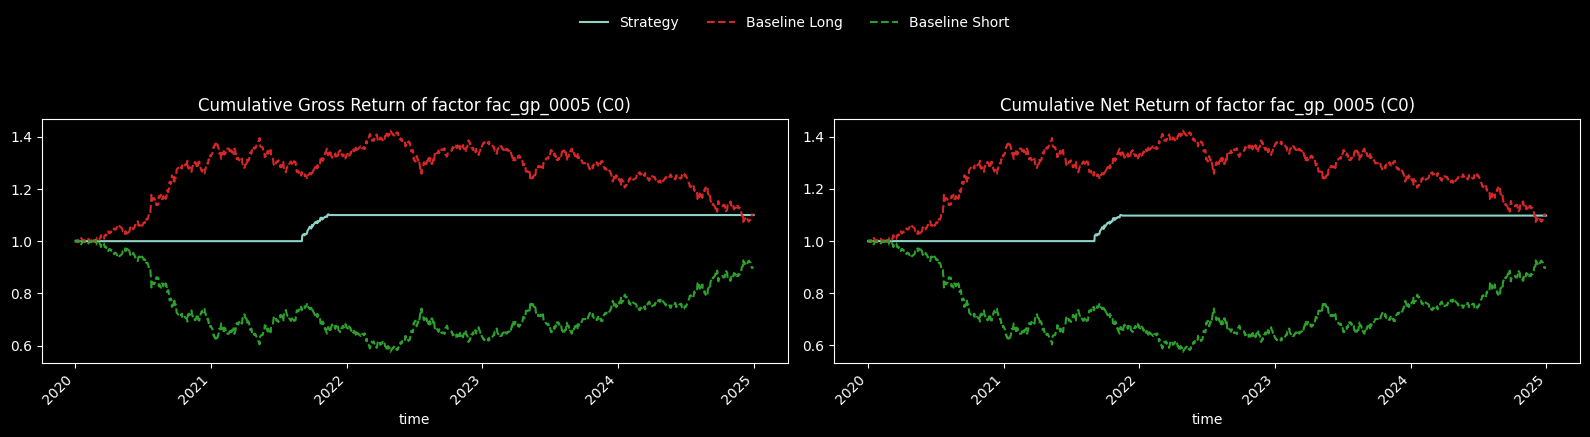

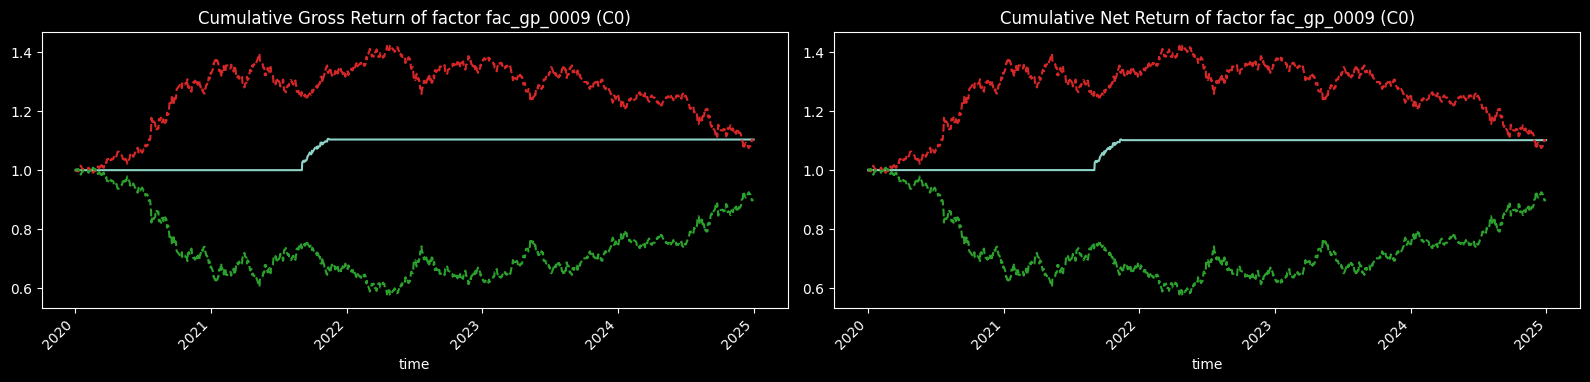

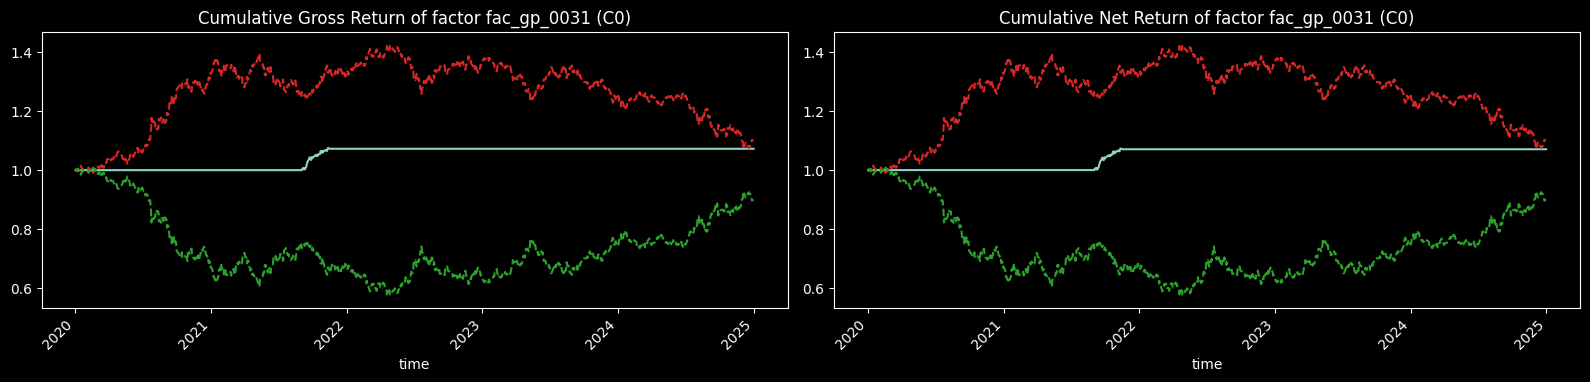

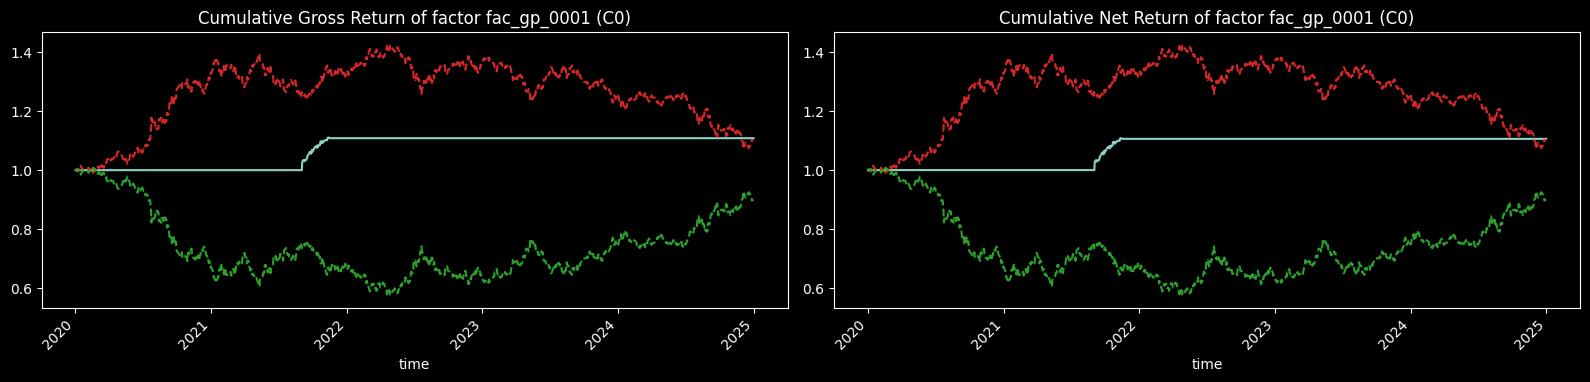

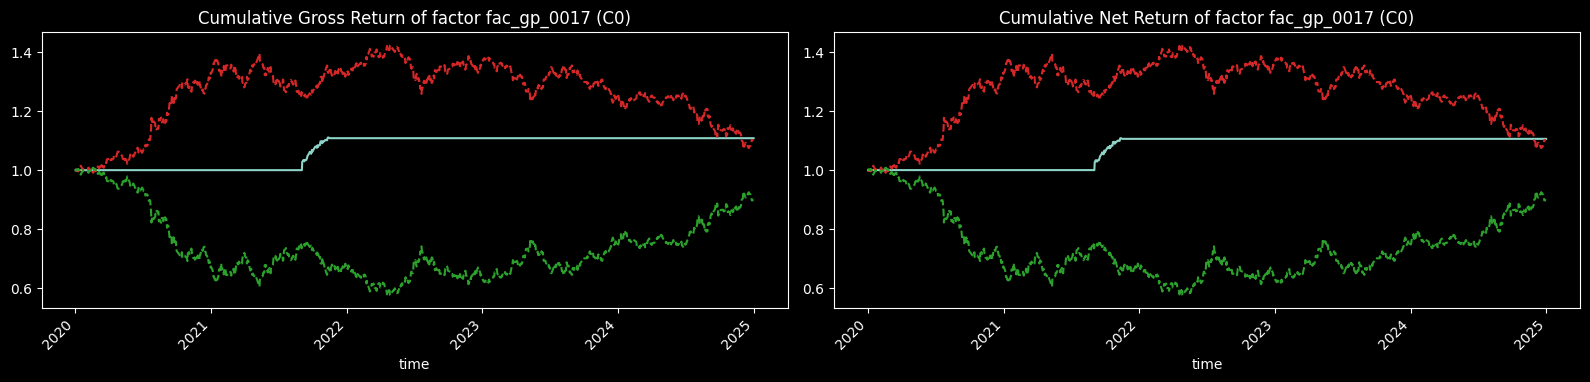

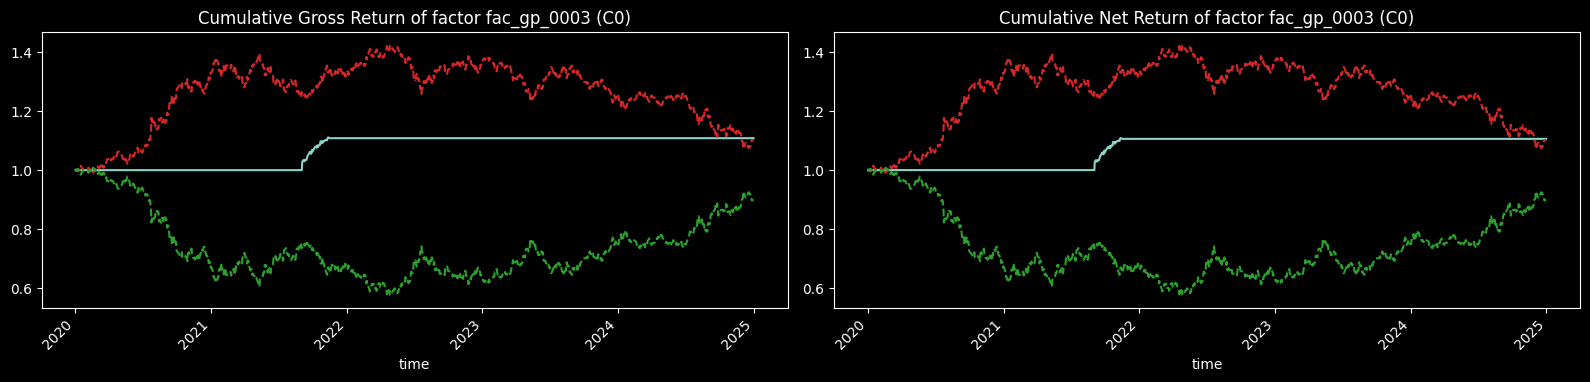

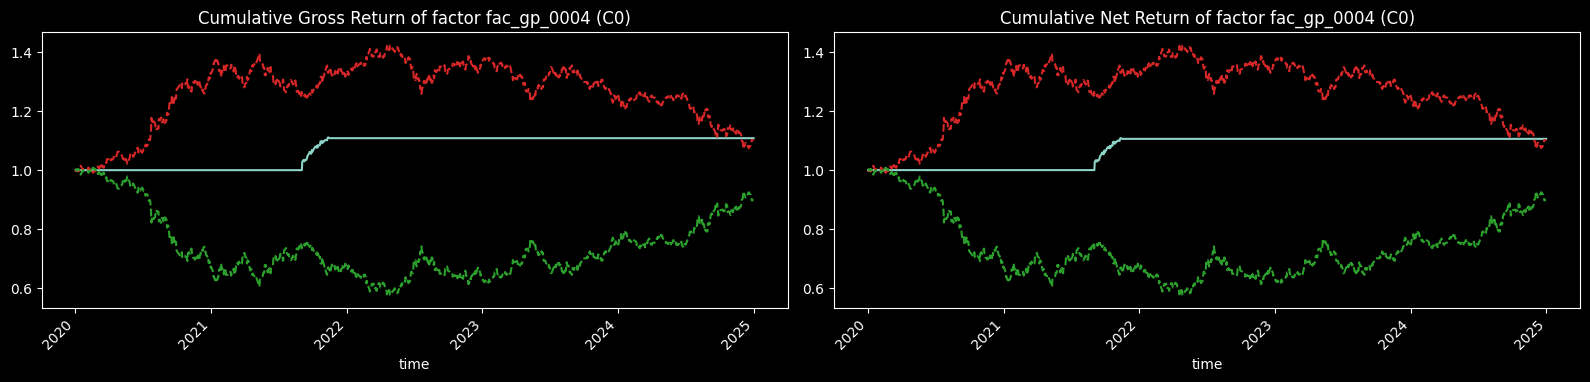

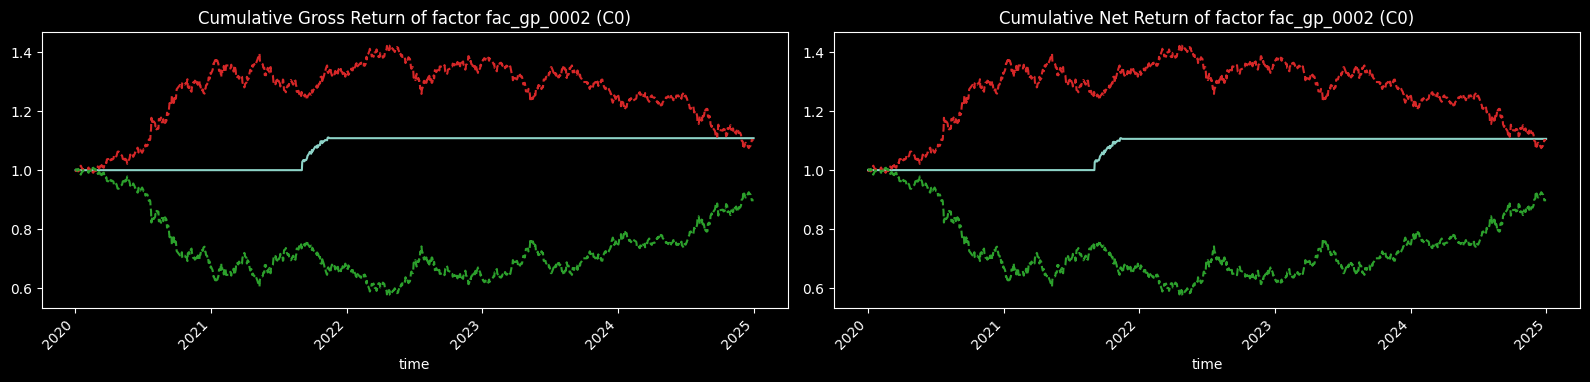

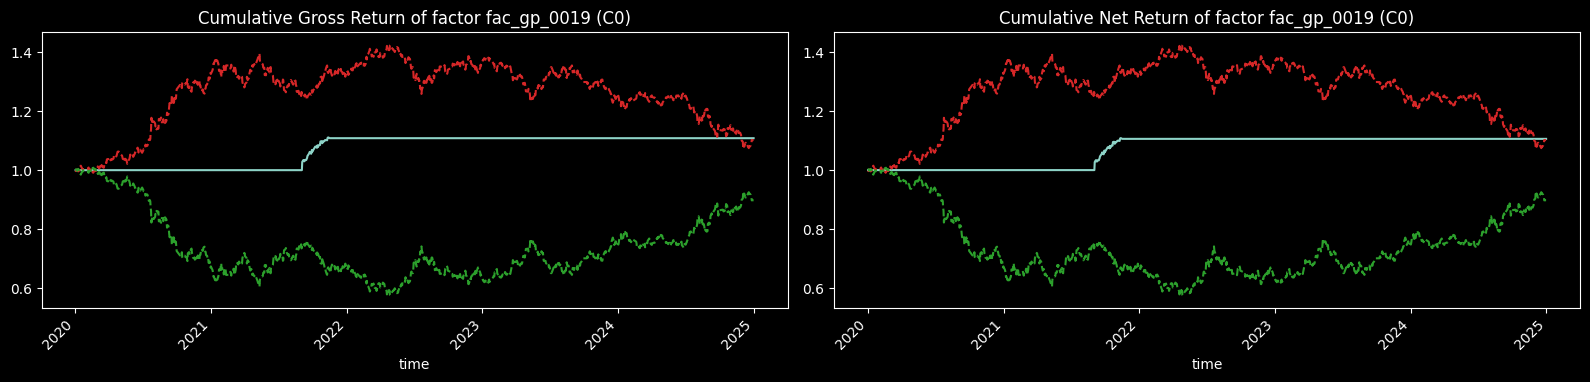

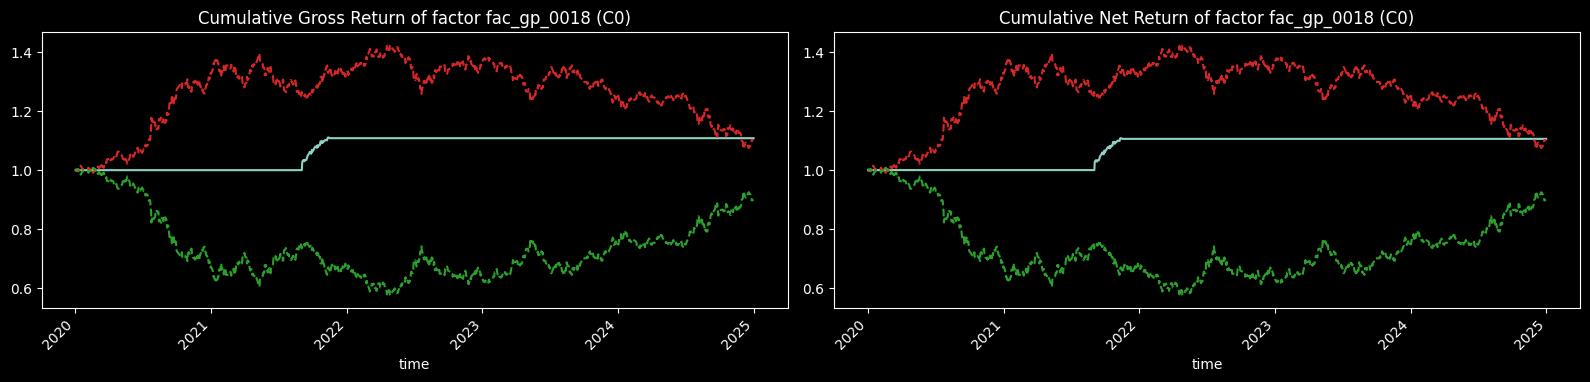

In [16]:
# 净值曲线
start_time = pd.to_datetime('20200101')
end_time = pd.to_datetime('20241231')
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=top_fc_name, show_baseline=True)

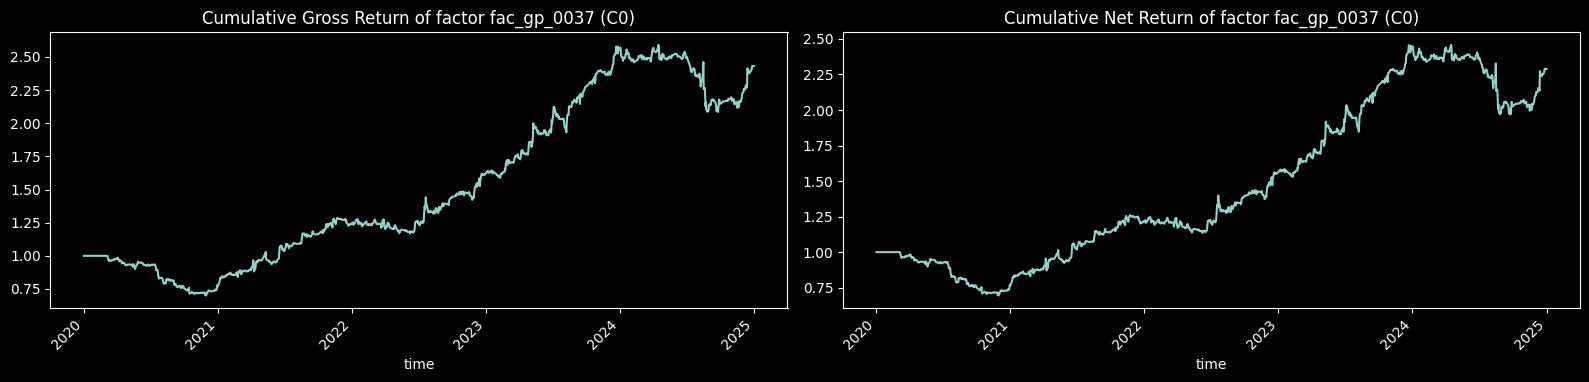

In [10]:
bt.plot_nav(start_time=start_time,
            end_time=end_time,
            fc_name=selected_fc_name_list, show_baseline=False)